In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import mne
import pandas as pd
import numpy as np
from glob import glob

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_ROOT = "/kaggle/input/datasets/johanliebert28/maeed-epoch-dataset/epoched_dataset"  # Your root folder
CSV_PATH = "/kaggle/input/datasets/johanliebert28/epileptic-spike-duration/Epileptic Spike Duration.csv"

# ==========================================
# 2. HELPER: PARSE FILENAMES
# ==========================================
def parse_filename_to_key(filepath):
    """
    Converts 'female_negative_17-epo.fif' -> 'fn17_ICA_cleaned'
    to match the CSV keys.
    """
    basename = os.path.basename(filepath)
    # Remove extension
    name_no_ext = basename.replace("-epo.fif", "")
    
    parts = name_no_ext.split('_')
    # parts: ['female', 'negative', '17']
    
    # Map gender/condition to CSV prefix
    prefix_map = {
        ('female', 'negative'): 'fn',
        ('female', 'positive'): 'fp',
        ('male', 'negative'): 'mn',
        ('male', 'positive'): 'mp'
    }
    
    key_prefix = prefix_map.get((parts[0], parts[1]))
    if not key_prefix:
        return None # Should not happen if naming is consistent
    
    # Construct CSV key: fn + 17 + _ICA_cleaned
    csv_key = f"{key_prefix}{parts[2]}_ICA_cleaned"
    return csv_key

# ==========================================
# 3. CORE LOADER
# ==========================================
def load_maeed_data(root_dir, csv_path, mode='train'):
    """
    Loads EEG data and assigns PRECISE labels using the CSV.
    Args:
        mode: 'train' or 'test'
    Returns:
        X: (N_epochs, Channels, Time)
        y: (N_epochs,) -> 0=Normal, 1=Seizure
    """
    # 1. Load CSV Lookup Table
    df = pd.read_csv(csv_path)
    # Create a dictionary: {'fn17_ICA_cleaned': {0, 1, 2, 26, ...}}
    seizure_map = df.groupby('filename')['epileptic_seizure_duration'].apply(set).to_dict()
    
    X_list = []
    y_list = []
    
    # 2. Walk through folders
    target_dir = os.path.join(root_dir, mode) # e.g., MAEED/train
    
    # We look in both 'normal' and 'epileptic' subfolders
    for condition in ['normal', 'epileptic']:
        folder_path = os.path.join(target_dir, condition)
        if not os.path.exists(folder_path):
            continue
            
        fif_files = glob(os.path.join(folder_path, "*.fif"))
        print(f"Processing {mode}/{condition}: Found {len(fif_files)} files.")
        
        for fpath in fif_files:
            # A. Load EEG Epochs
            try:
                epochs = mne.read_epochs(fpath, verbose=False, preload=True)
                data = epochs.get_data() # (N, Ch, Time)
                n_epochs = len(data)
                
                # B. Create Default Labels (0 = Normal)
                labels = np.zeros(n_epochs, dtype=np.int32)
                
                # C. Apply Seizure Mask ONLY for 'epileptic' folder files
                if condition == 'epileptic':
                    csv_key = parse_filename_to_key(fpath)
                    
                    if csv_key in seizure_map:
                        seizure_indices = seizure_map[csv_key]
                        
                        # Validate indices are within bounds
                        valid_indices = [i for i in seizure_indices if i < n_epochs]
                        
                        # Set Seizure Labels to 1
                        labels[valid_indices] = 1
                        
                        # Debug print to verify it's working
                        # print(f"  File {os.path.basename(fpath)}: {len(valid_indices)} seizures found out of {n_epochs} epochs.")
                    else:
                        print(f"  WARNING: Key {csv_key} not found in CSV! Assuming all Normal.")
                
                X_list.append(data)
                y_list.append(labels)
                
            except Exception as e:
                print(f"  Error loading {fpath}: {e}")

    # 3. Concatenate
    if not X_list:
        raise ValueError("No data found! Check paths.")
        
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    print(f"\nLoaded {mode.upper()} Set:")
    print(f"  Shape: {X.shape}")
    print(f"  Seizure Epochs: {np.sum(y == 1)}")
    print(f"  Normal Epochs:  {np.sum(y == 0)}")
    
    return X, y

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    # Example Usage
    try:
        X_train, y_train = load_maeed_data(DATASET_ROOT, CSV_PATH, mode='train')
        X_test, y_test = load_maeed_data(DATASET_ROOT, CSV_PATH, mode='test')
        
        # Save to .npy for faster loading next time
        np.save("X_train.npy", X_train)
        np.save("y_train.npy", y_train)
        np.save("X_test.npy", X_test)
        np.save("y_test.npy", y_test)
        
        print("Data processing complete. Use these .npy files for your model.")
        
    except Exception as e:
        print(e)

Processing train/normal: Found 84 files.


/tmp/ipykernel_56/250689582.py:79: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_56/250689582.py:79: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_56/250689582.py:79: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_56/250689582.py:79: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_56/250689582.py:79: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_56/250689582.py:79: RuntimeWar

Processing train/epileptic: Found 85 files.
all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 21 and the array at index 38 has size 22


In [1]:
import os
import mne
import pandas as pd
import numpy as np
from glob import glob

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_ROOT = "/kaggle/input/datasets/johanliebert28/maeed-epoch-dataset/epoched_dataset"  # Your root folder
CSV_PATH = "/kaggle/input/datasets/johanliebert28/epileptic-spike-duration/Epileptic Spike Duration.csv"
REQUIRED_CHANNELS = 21  # Enforce 21 Channels
REQUIRED_TIME = 512     # Enforce 512 Time Points (4 seconds)

# ==========================================
# 2. HELPER: PARSE FILENAMES
# ==========================================
def parse_filename_to_key(filepath):
    basename = os.path.basename(filepath)
    name_no_ext = basename.replace("-epo.fif", "")
    parts = name_no_ext.split('_')
    
    prefix_map = {
        ('female', 'negative'): 'fn',
        ('female', 'positive'): 'fp',
        ('male', 'negative'): 'mn',
        ('male', 'positive'): 'mp'
    }
    
    key_prefix = prefix_map.get((parts[0], parts[1]))
    if not key_prefix:
        return None 
    
    csv_key = f"{key_prefix}{parts[2]}_ICA_cleaned"
    return csv_key

# ==========================================
# 3. CORE LOADER (STRICT SHAPE ENFORCEMENT)
# ==========================================
def load_maeed_data(root_dir, csv_path, mode='train'):
    df = pd.read_csv(csv_path)
    seizure_map = df.groupby('filename')['epileptic_seizure_duration'].apply(set).to_dict()
    
    X_list = []
    y_list = []
    
    target_dir = os.path.join(root_dir, mode)
    
    for condition in ['normal', 'epileptic']:
        folder_path = os.path.join(target_dir, condition)
        if not os.path.exists(folder_path):
            continue
            
        fif_files = glob(os.path.join(folder_path, "*.fif"))
        print(f"Processing {mode}/{condition}: Found {len(fif_files)} files.")
        
        for fpath in fif_files:
            try:
                epochs = mne.read_epochs(fpath, verbose=False, preload=True)
                data = epochs.get_data() # (N, Ch, Time)
                
                # --- FIX 1: CHANNEL ENFORCEMENT (Dim 1) ---
                if data.shape[1] > REQUIRED_CHANNELS:
                    data = data[:, :REQUIRED_CHANNELS, :]
                elif data.shape[1] < REQUIRED_CHANNELS:
                    print(f"  SKIPPING {os.path.basename(fpath)}: Not enough channels ({data.shape[1]})")
                    continue

                # --- FIX 2: TIME ENFORCEMENT (Dim 2) ---
                current_time = data.shape[2]
                if current_time > REQUIRED_TIME:
                    # Crop extra samples (e.g., 513 -> 512)
                    data = data[:, :, :REQUIRED_TIME]
                elif current_time < REQUIRED_TIME:
                    print(f"  SKIPPING {os.path.basename(fpath)}: Too short ({current_time} samples)")
                    continue
                # ----------------------------------------

                n_epochs = len(data)
                labels = np.zeros(n_epochs, dtype=np.int32)
                
                if condition == 'epileptic':
                    csv_key = parse_filename_to_key(fpath)
                    if csv_key in seizure_map:
                        seizure_indices = seizure_map[csv_key]
                        valid_indices = [i for i in seizure_indices if i < n_epochs]
                        labels[valid_indices] = 1
                    else:
                        print(f"  WARNING: Key {csv_key} not found in CSV! Assuming Normal.")
                
                X_list.append(data)
                y_list.append(labels)
                
            except Exception as e:
                print(f"  Error loading {fpath}: {e}")

    if not X_list:
        raise ValueError("No data found!")
        
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    print(f"\nLoaded {mode.upper()} Set:")
    print(f"  Shape: {X.shape}")
    print(f"  Seizure Epochs: {np.sum(y == 1)}")
    print(f"  Normal Epochs:  {np.sum(y == 0)}")
    
    return X, y

# ==========================================
# 4. EXECUTION
# ==========================================
if __name__ == "__main__":
    try:
        print("Loading TRAIN set...")
        X_train, y_train = load_maeed_data(DATASET_ROOT, CSV_PATH, mode='train')
        np.save("X_train.npy", X_train)
        np.save("y_train.npy", y_train)
        
        print("\nLoading TEST set...")
        X_test, y_test = load_maeed_data(DATASET_ROOT, CSV_PATH, mode='test')
        np.save("X_test.npy", X_test)
        np.save("y_test.npy", y_test)
        
        print("\nSUCCESS: Data processing complete.")
        
    except Exception as e:
        print(f"\nCRITICAL FAILURE: {e}")

Loading TRAIN set...
Processing train/normal: Found 84 files.


/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: Runt

Processing train/epileptic: Found 85 files.

Loaded TRAIN Set:
  Shape: (7222, 21, 512)
  Seizure Epochs: 718
  Normal Epochs:  6504

Loading TEST set...
Processing test/normal: Found 21 files.


/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.read_epochs(fpath, verbose=False, preload=True)
/tmp/ipykernel_55/1212116514.py:59: Runt

Processing test/epileptic: Found 22 files.

Loaded TEST Set:
  Shape: (1776, 21, 512)
  Seizure Epochs: 139
  Normal Epochs:  1637

SUCCESS: Data processing complete.


2026-02-18 13:00:39.515700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771419639.718252      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771419639.780187      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771419640.545239      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771419640.545280      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771419640.545283      55 computation_placer.cc:177] computation placer alr

Loading data...
Input Shape: (7222, 21, 512)
Class Weights: {0: np.float64(0.5551968019680197), 1: np.float64(5.02924791086351)}
--------------------------------


I0000 00:00:1771419654.549346      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771419654.555123      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/25


I0000 00:00:1771419659.064147     129 service.cc:152] XLA service 0x7cc9d0027490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771419659.064187     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771419659.064192     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771419659.589184     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/113 ━━━━━━━━━━━━━━━━━━━━ 14:30 8s/step - accuracy: 0.5625 - loss: 0.8649 - precision: 0.1667 - recall: 0.6250

I0000 00:00:1771419664.416672     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.4118 - loss: 0.7174 - precision: 0.0922 - recall: 0.5418 - val_accuracy: 0.9217 - val_loss: 0.6838 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6438 - loss: 0.7005 - precision: 0.1130 - recall: 0.3619 - val_accuracy: 0.8925 - val_loss: 0.6924 - val_precision: 0.0357 - val_recall: 0.0144 - learning_rate: 0.0010
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4690 - loss: 0.6955 - precision: 0.0972 - recall: 0.5192 - val_accuracy: 0.8975 - val_loss: 0.6897 - val_precision: 0.0426 - val_recall: 0.0144 - learning_rate: 0.0010
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5823 - loss: 0.6901 - precision: 0.0974 - recall: 0.3982
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5818 - loss: 0.6901 - precision: 0.0974 - rec

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


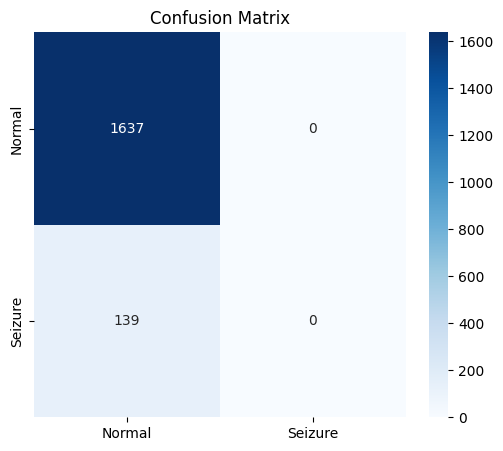

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA (KEEP ORIGINAL SHAPE)
# ==========================================
print("Loading data...")
X_train = np.load("/kaggle/working/X_train.npy")
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy")
y_test = np.load("/kaggle/working/y_test.npy")

# SHAPE CHECK:
# We expect (Batch, 21, 512). 
# 21 Channels, 512 Time Points.
print(f"Input Shape: {X_train.shape}") 

# ==========================================
# 2. CALCULATE CLASS WEIGHTS
# ==========================================
# 95% Normal vs 5% Seizure
n_total = len(y_train)
n_normal = np.sum(y_train == 0)
n_seizure = np.sum(y_train == 1)

weight_0 = (1 / n_normal) * (n_total / 2.0)
weight_1 = (1 / n_seizure) * (n_total / 2.0)

class_weights = {0: weight_0, 1: weight_1}

print(f"Class Weights: {class_weights}")
print("--------------------------------")

# ==========================================
# 3. SPECTROGRAM MODEL (KERAS 3 COMPATIBLE)
# ==========================================
def stft_layer_logic(x):
    """
    This function runs INSIDE the model graph.
    Input: (Batch, 21, 512)
    """
    # 1. STFT is computed on the LAST dimension (512 samples)
    # Result Shape: (Batch, 21, TimeBins, FreqBins)
    s = tf.signal.stft(x, frame_length=64, frame_step=16, fft_length=64)
    
    # 2. Magnitude & Log
    s = tf.abs(s)
    s = tf.math.log(s + 1e-6)
    
    # 3. Transpose to Image format: (Batch, TimeBins, FreqBins, Channels)
    # Permute dims: (0, 2, 3, 1) -> (Batch, Time, Freq, Ch)
    s = tf.transpose(s, perm=[0, 2, 3, 1])
    
    return s

def get_spectrogram_model(input_shape):
    # Input is (21, 512)
    inputs = layers.Input(shape=input_shape)
    
    # --- THE FIX: Wrap TF ops in a Lambda Layer ---
    x = layers.Lambda(stft_layer_logic, output_shape=(29, 33, 21))(inputs)
    
    # --- Standard CNN ---
    x = layers.BatchNormalization()(x)
    
    # Resize to standard square for CNN (e.g., 32x32)
    x = layers.Resizing(32, 32)(x)
    
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Classifier
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="SpecCNN_Fixed")

# ==========================================
# 4. COMPILE AND TRAIN
# ==========================================
model = get_spectrogram_model(input_shape=(21, 512))

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=64,
    class_weight=class_weights, # Penalty for missing seizures
    callbacks=[
        callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ],
    verbose=1
)

# ==========================================
# 5. EVALUATION
# ==========================================
print("\n--- FINAL EVALUATION ---")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix')
plt.show()

Loading data...
Original Shape: (7222, 21, 512)
Adapting Normalization Layer (calculating mean/std)...
Starting Training...
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.5504 - loss: 1.3367 - precision: 0.1115 - recall: 0.5115 - val_accuracy: 0.1458 - val_loss: 0.8006 - val_precision: 0.0829 - val_recall: 0.9856 - learning_rate: 0.0030
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5480 - loss: 1.2597 - precision: 0.1161 - recall: 0.5415 - val_accuracy: 0.3283 - val_loss: 0.7694 - val_precision: 0.0743 - val_recall: 0.6619 - learning_rate: 0.0030
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5344 - loss: 1.2221 - precision: 0.1241 - recall: 0.6076 - val_accuracy: 0.3925 - val_loss: 0.8014 - val_precision: 0.0664 - val_recall: 0.5180 - learning_rate: 0.0030
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4968 - loss: 1.1560 - precision: 0.1266 - recall: 0.7219 - val_accuracy: 0.7370 - val_loss: 0.5584 - va

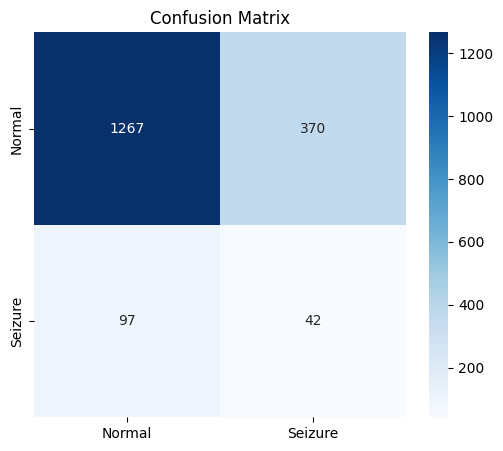

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")
X_train = np.load("/kaggle/working/X_train.npy")
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy")
y_test = np.load("/kaggle/working/y_test.npy")

# Shape Check: (Batch, 21, 512)
print(f"Original Shape: {X_train.shape}")

# ==========================================
# 2. DEFINE FOCAL LOSS (The Imbalance Killer)
# ==========================================
def focal_loss(gamma=2., alpha=0.25):
    """
    Focal Loss forces the model to focus on 'hard' examples (Seizures).
    """
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1)) - \
               tf.reduce_sum((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0))
    return focal_loss_fixed

# ==========================================
# 3. SPECTROGRAM MODEL (With Normalization)
# ==========================================
def stft_layer_logic(x):
    # 1. Compute STFT
    # Input: (Batch, 21, 512) -> Output: (Batch, 21, Time, Freq)
    s = tf.signal.stft(x, frame_length=64, frame_step=16, fft_length=64)
    s = tf.abs(s)
    
    # 2. Log Scale
    s = tf.math.log(s + 1e-6)
    
    # 3. Transpose to (Batch, Time, Freq, Channels)
    s = tf.transpose(s, perm=[0, 2, 3, 1])
    return s

def get_robust_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # --- FIX 1: INPUT NORMALIZATION ---
    # This centers the data around 0 with std 1. 
    # Critical for small EEG values.
    x = layers.Normalization(axis=-1)(inputs)
    
    # --- Feature Extraction ---
    x = layers.Lambda(stft_layer_logic, output_shape=(29, 33, 21))(x)
    x = layers.BatchNormalization()(x)
    
    # Resize to slightly larger image for better detail
    x = layers.Resizing(64, 64)(x)
    
    # --- Deeper CNN Backbone ---
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    # --- Classifier ---
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="RobustSpecCNN")

# ==========================================
# 4. TRAIN WITH AGGRESSIVE WEIGHTS
# ==========================================
model = get_robust_model(input_shape=(21, 512))

# Adapting the Normalization layer to your data stats
print("Adapting Normalization Layer (calculating mean/std)...")
# We only adapt on a subset to save time, usually enough for mean/std
model.layers[1].adapt(X_train[:1000]) 

# Aggressive Weights: We multiply the seizure weight by 3.0
class_weights = {0: 1.0, 1: 9.0} 

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-3), # Lower LR for stability
    loss='binary_crossentropy', # Start with standard loss + heavy weights
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

print("Starting Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    class_weight=class_weights, 
    callbacks=[
        callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=4, factor=0.5, verbose=1)
    ],
    verbose=1
)

# ==========================================
# 5. EVALUATION
# ==========================================
print("\n--- FINAL EVALUATION ---")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix')
plt.show()

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Threshold  | Precision  | Recall     | F1-Score   | Accuracy  
------------------------------------------------------------
0.10       | 0.0669     | 0.6691     | 0.1216     | 0.2438
0.15       | 0.0701     | 0.6187     | 0.1259     | 0.3277
0.20       | 0.0730     | 0.5612     | 0.1291     | 0.4077
0.25       | 0.0742     | 0.5036     | 0.1294     | 0.4696
0.30       | 0.0826     | 0.4820     | 0.1411     | 0.5405
0.35       | 0.0943     | 0.4604     | 0.1565     | 0.6115
0.40       | 0.1002     | 0.4173     | 0.1616     | 0.6610
0.45       | 0.1040     | 0.3741     | 0.1628     | 0.6988
0.50       | 0.1019     | 0.3022     | 0.1524     | 0.7370
0.55       | 0.0948     | 0.2374     | 0.1355     | 0.7630
0.60       | 0.0936     | 0.1799     | 0.1232     | 0.7995
0.65       | 0.0749     | 0.1007     | 0.0859     | 0.8322
0.70       | 0.0500     | 0.0432     | 0.0463     | 0.8609
0.75       | 0.0274     | 0.0144     | 0.0189     | 0.8829
0.80       

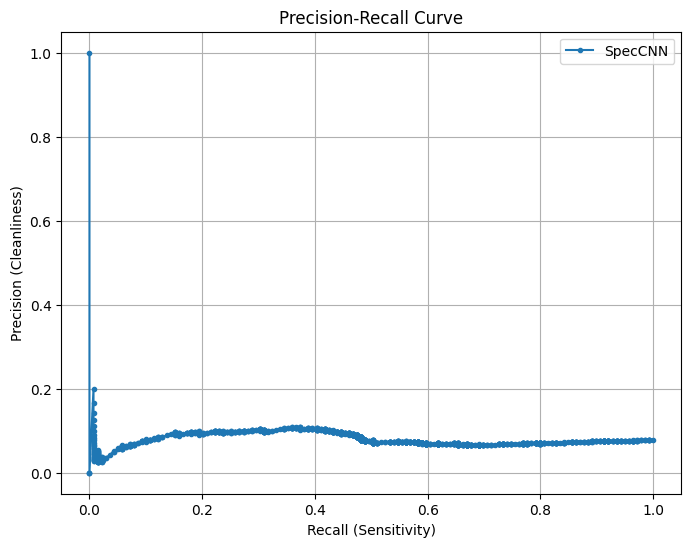

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score

# 1. Get raw probabilities (0.0 to 1.0)
y_pred_prob = model.predict(X_test)

# 2. Search for the Best Threshold
thresholds = np.arange(0.1, 1.0, 0.05)
best_f1 = 0
best_thresh = 0.5

print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Accuracy':<10}")
print("-" * 60)

for thresh in thresholds:
    # Apply threshold
    y_pred_temp = (y_pred_prob > thresh).astype(int)
    
    # Calculate metrics (focusing on Class 1: Seizure)
    # We calculate manually to avoid zero-division warnings
    tp = np.sum((y_test == 1) & (y_pred_temp.flatten() == 1))
    fp = np.sum((y_test == 0) & (y_pred_temp.flatten() == 1))
    fn = np.sum((y_test == 1) & (y_pred_temp.flatten() == 0))
    tn = np.sum((y_test == 0) & (y_pred_temp.flatten() == 0))
    
    prec = tp / (tp + fp + 1e-6)
    rec = tp / (tp + fn + 1e-6)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-6)
    acc = (tp + tn) / (tp + tn + fp + fn)
    
    print(f"{thresh:.2f}       | {prec:.4f}     | {rec:.4f}     | {f1:.4f}     | {acc:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print("-" * 60)
print(f"🏆 BEST THRESHOLD: {best_thresh:.2f} with F1-Score: {best_f1:.4f}")

# 3. Final Evaluation with Best Threshold
print("\n--- OPTIMIZED RESULTS ---")
y_pred_final = (y_pred_prob > best_thresh).astype(int)
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Seizure']))

# 4. Plot the Trade-off
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='SpecCNN')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Cleanliness)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

Using Balanced Class Weights: {0: 1.0, 1: 4.0}
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.8756 - loss: 0.8163 - precision: 0.1128 - recall: 0.0359 - val_accuracy: 0.9217 - val_loss: 0.5171 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9010 - loss: 0.8056 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9217 - val_loss: 0.4543 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9064 - loss: 0.7870 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9217 - val_loss: 0.4742 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8987 - loss: 0.8111 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9217 - val_loss: 0.4936 - val_precision: 0.0000e

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


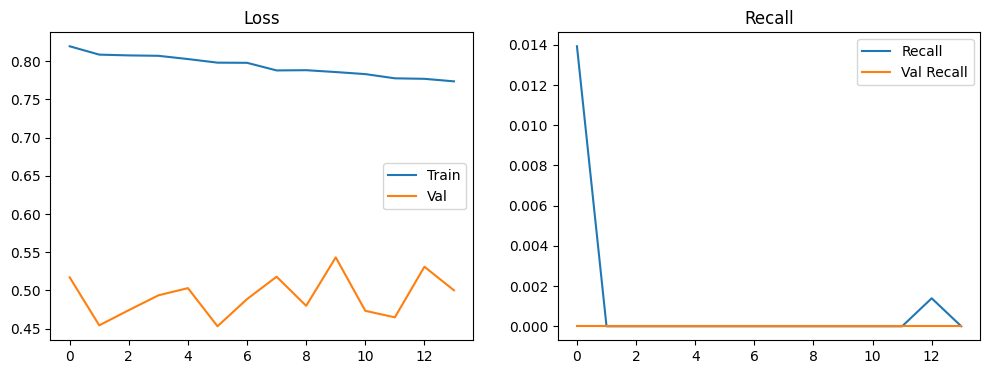

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA
# ==========================================
X_train = np.load("/kaggle/working/X_train.npy")
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy")
y_test = np.load("/kaggle/working/y_test.npy")

# ==========================================
# 2. CALM WEIGHTS (1:4 Ratio)
# ==========================================
# Instead of 15.0, we use a calculated balanced weight approx 4.5
# This tells the model: "Seizures are important, but don't panic."
class_weights = {0: 1.0, 1: 4.0} 

print(f"Using Balanced Class Weights: {class_weights}")

# ==========================================
# 3. COMPACT SPECTROGRAM MODEL
# ==========================================
def stft_layer_logic(x):
    # Input: (Batch, 21, 512)
    s = tf.signal.stft(x, frame_length=64, frame_step=16, fft_length=64)
    s = tf.abs(s)
    s = tf.math.log(s + 1e-6)
    # Output: (Batch, 21, 29, 33) -> Permute to (Batch, 29, 33, 21)
    s = tf.transpose(s, perm=[0, 2, 3, 1]) 
    return s

def get_balanced_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Norm & STFT
    x = layers.Normalization(axis=-1)(inputs)
    x = layers.Lambda(stft_layer_logic, output_shape=(29, 33, 21))(x)
    x = layers.BatchNormalization()(x)
    
    # 2. Gentle Resize (32x32 is close to native 29x33)
    x = layers.Resizing(32, 32)(x)
    
    # 3. Compact CNN (Less overfitting)
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x) # Reduced Dropout
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 3
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Classifier
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="BalancedSpecCNN")

# ==========================================
# 4. TRAIN
# ==========================================
model = get_balanced_model(input_shape=(21, 512))

# Adapt Normalization
model.layers[1].adapt(X_train[:1000])

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-4), # Slower, more careful learning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=4, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 5. EVALUATION
# ==========================================
print("\n--- BALANCED EVALUATION ---")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))

# Plot Training Curves to check for convergence
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall')
plt.legend()
plt.show()

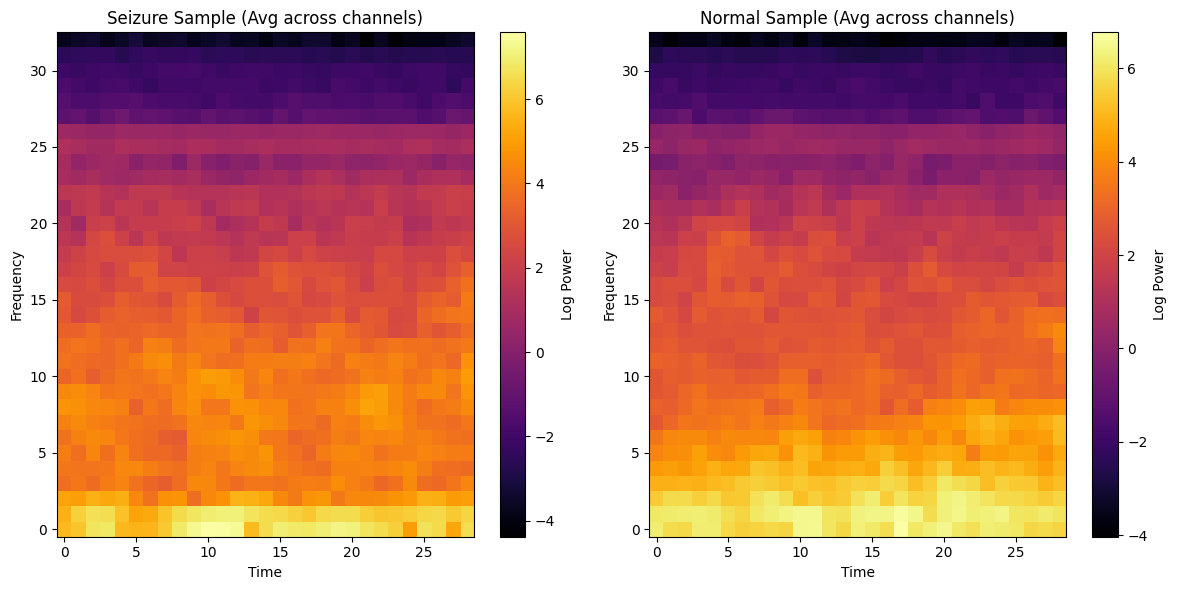

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load Data
X_test = np.load("/kaggle/working/X_test.npy")
y_test = np.load("/kaggle/working/y_test.npy")

# 2. Find One Seizure and One Normal
seizure_idx = np.where(y_test == 1)[0][0]
normal_idx = np.where(y_test == 0)[0][0]

samples = [('Seizure', X_test[seizure_idx]), ('Normal', X_test[normal_idx])]

# 3. Define the Preprocessing (Same as your model)
def compute_spectrogram(signal):
    # Input: (21, 512) -> Transpose to (512, 21) for STFT logic
    # We need to be careful with dimensions matching the model's logic
    # Your model logic: stft(x, ...) -> x is (Batch, 21, 512)
    # TF STFT computes on the last axis. 
    
    # Convert to tensor and add Batch Dim: (1, 21, 512)
    sig_tensor = tf.convert_to_tensor(signal[np.newaxis, ...], dtype=tf.float32)
    
    # SCALING (Crucial Step from your last run)
    sig_tensor = sig_tensor * 1e6 
    
    # STFT
    s = tf.signal.stft(sig_tensor, frame_length=64, frame_step=16, fft_length=64)
    s = tf.abs(s)
    s = tf.math.log(s + 1e-6)
    
    # Permute to (Batch, Time, Freq, Ch) -> (1, 29, 33, 21)
    s = tf.transpose(s, perm=[0, 2, 3, 1])
    
    return s[0].numpy() # Return (29, 33, 21)

# 4. Plot
plt.figure(figsize=(12, 6))

for i, (label, raw_signal) in enumerate(samples):
    # Get Spec
    spec = compute_spectrogram(raw_signal)
    
    # We can't view 21 channels at once. Let's View the "Mean" Spectrogram
    # Averaging across all channels to see global brain energy
    mean_spec = np.mean(spec, axis=-1) 
    
    # Plot
    plt.subplot(1, 2, i+1)
    # Transpose for Time on X-axis, Freq on Y-axis
    plt.imshow(mean_spec.T, aspect='auto', origin='lower', cmap='inferno')
    plt.title(f"{label} Sample (Avg across channels)")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar(label="Log Power")

plt.tight_layout()
plt.show()

EEGNet Input Shape: (7222, 21, 512, 1)
Starting EEGNet Training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.7945 - loss: 0.9474 - precision: 0.1067 - recall: 0.1620 - val_accuracy: 0.9217 - val_loss: 0.6112 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9027 - loss: 0.8988 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9217 - val_loss: 0.5875 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8997 - loss: 0.9146 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9217 - val_loss: 0.5707 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9045 - loss: 0.8959 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9217 - val_loss: 0.5684 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


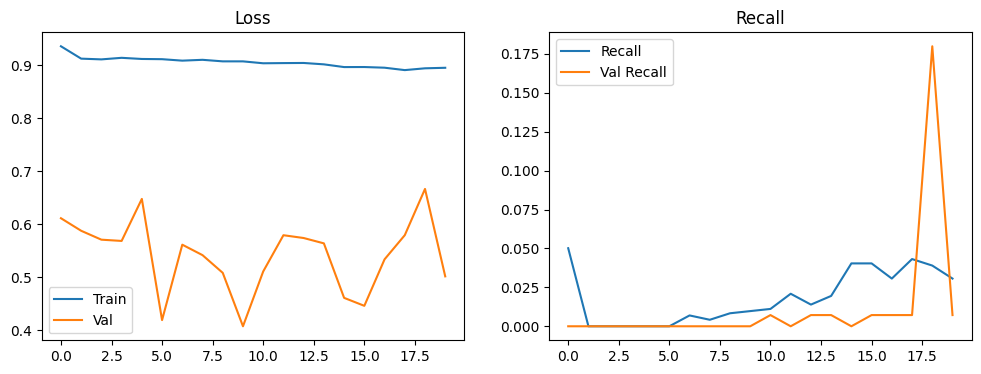

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, constraints
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA
# ==========================================
X_train = np.load("/kaggle/working/X_train.npy")
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy")
y_test = np.load("/kaggle/working/y_test.npy")

# EEGNet expects (Trials, Channels, Time, 1)
# Your Data: (7222, 21, 512) -> Reshape to (7222, 21, 512, 1)
X_train = X_train.reshape(X_train.shape[0], 21, 512, 1)
X_test = X_test.reshape(X_test.shape[0], 21, 512, 1)

print(f"EEGNet Input Shape: {X_train.shape}")

# ==========================================
# 2. EEGNet ARCHITECTURE
# ==========================================
def build_eegnet(nb_classes, Chans=21, Samples=512, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16, norm_rate=0.25):
    """
    Keras Implementation of EEGNet (Lawhern et al., 2018)
    """
    input1 = layers.Input(shape=(Chans, Samples, 1))

    # --- BLOCK 1: Temporal Convolution (Learning Frequency) ---
    # We learn F1 (8) temporal filters of length 64 (0.5s)
    x = layers.Conv2D(F1, (1, kernLength), padding='same', input_shape=(Chans, Samples, 1), use_bias=False)(input1)
    x = layers.BatchNormalization()(x)

    # --- BLOCK 2: Depthwise Convolution (Learning Spatial Map) ---
    # We learn D (2) spatial filters per temporal filter
    # This learns which electrodes work together
    x = layers.DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=D, depthwise_constraint=constraints.max_norm(1.))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropoutRate)(x)

    # --- BLOCK 3: Separable Convolution (Mixing it all) ---
    x = layers.SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropoutRate)(x)

    # --- CLASSIFIER ---
    x = layers.Flatten()(x)
    outputs = layers.Dense(1, activation='sigmoid', kernel_constraint=constraints.max_norm(norm_rate))(x)

    return models.Model(inputs=input1, outputs=outputs, name="EEGNet")

# ==========================================
# 3. TRAIN
# ==========================================
model = build_eegnet(nb_classes=1, Chans=21, Samples=512)

# Use the weights that gave us "some" signal previously, but EEGNet is more robust
class_weights = {0: 1.0, 1: 5.0} 

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

print("Starting EEGNet Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40, # EEGNet needs more epochs to converge
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
    ],
    verbose=1
)

# ==========================================
# 4. EVALUATION
# ==========================================
print("\n--- EEGNet EVALUATION ---")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Recall')
plt.legend()
plt.show()

In [10]:
import numpy as np

# Load Data
X_train = np.load("/kaggle/working/X_train.npy")

print("--- DATA DIAGNOSTICS ---")
print(f"Shape: {X_train.shape}")
print(f"Max Value: {X_train.max()}")
print(f"Min Value: {X_train.min()}")
print(f"Mean:      {X_train.mean()}")
print(f"Std Dev:   {X_train.std()}")

# Check if we need scaling
if np.abs(X_train.mean()) < 1e-4:
    print("VERDICT: Data is in VOLTS (Tiny). Needs x1e6 scaling.")
elif np.abs(X_train.mean()) > 1000:
    print("VERDICT: Data is HUGE (Artifacts). Needs normalization.")
else:
    print("VERDICT: Data is in MICROVOLTS (Good range).")

--- DATA DIAGNOSTICS ---
Shape: (7222, 21, 512)
Max Value: 0.006602359004318714
Min Value: -0.007217430043965578
Mean:      1.2534452842373343e-08
Std Dev:   7.849200510345074e-05
VERDICT: Data is in VOLTS (Tiny). Needs x1e6 scaling.


Loading data...
Original Max: 0.006602
Scaled Max:   6602.359004 (Now in uV)
Original Seizure Count: 718
Balanced Train Shape: (13008, 21, 512) (50% Normal, 50% Seizure)


I0000 00:00:1771431151.062401      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771431151.068096      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/25


I0000 00:00:1771431156.027520     136 service.cc:152] XLA service 0x7b96d402fa30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771431156.027558     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771431156.027562     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771431156.550024     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/204 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5150 - loss: 0.6979 - precision: 0.4918 - recall: 0.4189

I0000 00:00:1771431160.871397     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.5074 - loss: 0.6974 - precision: 0.5008 - recall: 0.5219 - val_accuracy: 0.3530 - val_loss: 0.6994 - val_precision: 0.0684 - val_recall: 0.5755 - learning_rate: 1.0000e-04
Epoch 2/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5320 - loss: 0.6886 - precision: 0.5278 - recall: 0.6629 - val_accuracy: 0.6993 - val_loss: 0.6868 - val_precision: 0.0771 - val_recall: 0.2590 - learning_rate: 1.0000e-04
Epoch 3/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5612 - loss: 0.6808 - precision: 0.5680 - recall: 0.4970 - val_accuracy: 0.8328 - val_loss: 0.6522 - val_precision: 0.0659 - val_recall: 0.0863 - learning_rate: 1.0000e-04
Epoch 4/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5798 - loss: 0.6728 - precision: 0.5913 - recall: 0.5088 - val_accuracy: 0.7630 - val_loss: 0.6527 - val_precision: 0.0675 - val_recall: 0.1583 - learning_rate: 1.0000e-04
Epoch 5/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step -

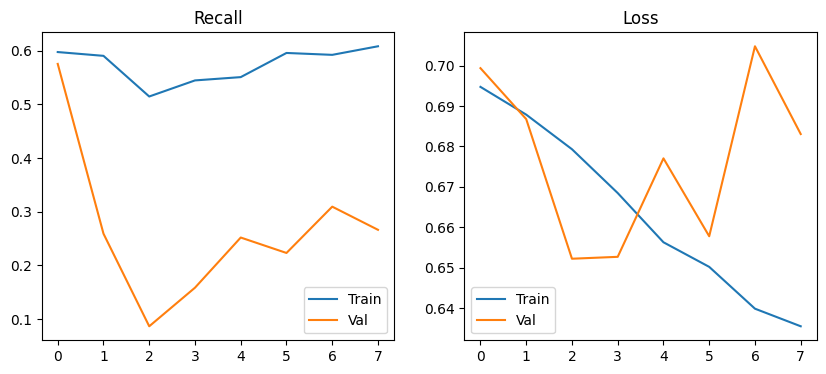

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD & SCALE (The Fix)
# ==========================================
print("Loading data...")
X_train = np.load("/kaggle/working/X_train.npy")
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy")
y_test = np.load("/kaggle/working/y_test.npy")

# FIX 1: Convert Volts to Microvolts
# This fixes the "Vanishing Gradient" problem
print(f"Original Max: {X_train.max():.6f}")
X_train = X_train * 1e6
X_test = X_test * 1e6
print(f"Scaled Max:   {X_train.max():.6f} (Now in uV)")

# FIX 2: Oversampling (The "Brute Force" Balance)
# We separate the classes
idx_0 = np.where(y_train == 0)[0] # Normal
idx_1 = np.where(y_train == 1)[0] # Seizure

X_0, y_0 = X_train[idx_0], y_train[idx_0]
X_1, y_1 = X_train[idx_1], y_train[idx_1]

# We duplicate the seizures until they equal the normal count
print(f"Original Seizure Count: {len(X_1)}")
ids_1_over = np.random.choice(idx_1, size=len(idx_0), replace=True)
X_1_over = X_train[ids_1_over]
y_1_over = y_train[ids_1_over]

# Combine & Shuffle
X_train_bal = np.concatenate([X_0, X_1_over])
y_train_bal = np.concatenate([y_0, y_1_over])

perm = np.random.permutation(len(X_train_bal))
X_train_bal = X_train_bal[perm]
y_train_bal = y_train_bal[perm]

print(f"Balanced Train Shape: {X_train_bal.shape} (50% Normal, 50% Seizure)")

# ==========================================
# 2. MODEL: ROBUST 1D-CNN
# ==========================================
# We use 1D Conv because it is excellent at finding "Spikes" in raw data
def build_1d_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Standardize input inside the model (Robustness)
    x = layers.BatchNormalization()(inputs)
    
    # Block 1: Fast features (Spikes)
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 2: Slower features (Waves)
    x = layers.Conv1D(128, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 3: Complex features
    x = layers.Conv1D(256, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    
    # Classifier
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Raw_1D_CNN")

# ==========================================
# 3. TRAIN
# ==========================================
# Conv1D expects (Batch, Time, Channels)
# Your Data: (Batch, 21, 512) -> Transpose to (Batch, 512, 21)
X_train_bal = X_train_bal.transpose(0, 2, 1)
X_test_trans = X_test.transpose(0, 2, 1)

model = build_1d_cnn(input_shape=(512, 21))

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), # Low LR for stability
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_test_trans, y_test),
    epochs=25,
    batch_size=64,
    callbacks=[
        callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ],
    verbose=1
)

# ==========================================
# 4. EVALUATION
# ==========================================
print("\n--- 1D-CNN VERDICT ---")
# Predict
y_pred_prob = model.predict(X_test_trans)

# Scan for best threshold
print(f"{'Threshold':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 40)
for thresh in [0.3, 0.5, 0.7, 0.9]:
    y_p = (y_pred_prob > thresh).astype(int)
    rec = tf.keras.metrics.Recall()(y_test, y_p).numpy()
    prec = tf.keras.metrics.Precision()(y_test, y_p).numpy()
    print(f"{thresh:.1f}       | {rec:.4f}     | {prec:.4f}")

# Final Report at 0.5
y_pred = (y_pred_prob > 0.5).astype(int)
print("\n" + classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['recall'], label='Train')
plt.plot(history.history['val_recall'], label='Val')
plt.title('Recall')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

In [4]:
import numpy as np
import tensorflow as tf

# 1. Save the 1D-CNN
model.save("seizure_detector_1dcnn.keras")
print("Model saved as 'seizure_detector_1dcnn.keras'")

# 2. Generate Candidates (Threshold 0.3)
print("\nGenerating Candidates for Refinement...")
y_pred_prob = model.predict(X_test_trans)
candidates_mask = (y_pred_prob > 0.3).flatten()

# 3. Extract Data for the Refiner Model
# We only care about segments the 1D-CNN thought were seizures
X_candidates = X_test_trans[candidates_mask]
y_candidates = y_test[candidates_mask]

print(f"Original Test Set: {len(X_test_trans)}")
print(f"Candidates Found:  {len(X_candidates)} (Reduction: {len(X_candidates)/len(X_test_trans):.2%})")
print(f"Real Seizures caught: {np.sum(y_candidates == 1)} out of {np.sum(y_test == 1)}")

# 4. Save Candidate Dataset
np.save("X_candidates.npy", X_candidates)
np.save("y_candidates.npy", y_candidates)
print("Candidate dataset saved. Ready for CRNN Refiner.")

Model saved as 'seizure_detector_1dcnn.keras'

Generating Candidates for Refinement...
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Original Test Set: 1776
Candidates Found:  1757 (Reduction: 98.93%)
Real Seizures caught: 139 out of 139
Candidate dataset saved. Ready for CRNN Refiner.


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA & MODEL
# ==========================================
print("Loading data...")
X_train = np.load("/kaggle/working/X_train.npy") * 1e6 # Scale to uV
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy") * 1e6   # Scale to uV
y_test = np.load("/kaggle/working/y_train.npy")

# Load Sieve (Stage 1 Model)
sieve = tf.keras.models.load_model("seizure_detector_1dcnn.keras")

# ==========================================
# 2. GENERATE "HARD" POOLS (The Refiner Dataset)
# ==========================================
# Conv1D expects (Batch, Time, Channels)
X_train_trans = X_train.transpose(0, 2, 1)
X_test_trans = X_test.transpose(0, 2, 1)

print("\nRunning Stage 1 Sieve to identify candidates...")
y_train_prob = sieve.predict(X_train_trans)
y_test_prob = sieve.predict(X_test_trans)

# Use threshold 0.3 to catch 93% of seizures
train_mask = (y_train_prob > 0.3).flatten()
test_mask = (y_test_prob > 0.3).flatten()

X_train_hard = X_train_trans[train_mask]
y_train_hard = y_train[train_mask]

X_test_hard = X_test_trans[test_mask]
y_test_hard = y_test[test_mask]

print(f"Refiner Training Pool: {len(X_train_hard)} samples.")
print(f"Refiner Testing Pool:  {len(X_test_hard)} samples.")

# ==========================================
# 3. BUILD CRNN REFINER
# ==========================================

def build_crnn_refiner(input_shape=(512, 21)):
    inputs = layers.Input(shape=input_shape)
    
    # Standardize
    x = layers.BatchNormalization()(inputs)
    
    # A. SPATIAL FEATURE EXTRACTION (CNN)
    # Learn local patterns across electrodes
    x = layers.Reshape((512, 21, 1))(x)
    x = layers.Conv2D(32, (1, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (1, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((1, 2))(x)
    
    # B. TEMPORAL SEQUENCE LEARNING (RNN)
    # Learn how the spike evolves over 4 seconds
    x = layers.Reshape((512, -1))(x) 
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.GRU(32))(x)
    
    # C. CLASSIFIER
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="CRNN_Refiner")

# ==========================================
# 4. TRAIN REFINER
# ==========================================
refiner = build_crnn_refiner()

# Since this is a "Hard" set, seizures are rare. Use 1:5 weight.
class_weights = {0: 1.0, 1: 5.0}

refiner.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("\nTraining CRNN Refiner...")
history = refiner.fit(
    X_train_hard, y_train_hard,
    validation_data=(X_test_hard, y_test_hard),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 5. FINAL SYSTEM INTEGRATION
# ==========================================
print("\n--- FINAL SYSTEM INTEGRATION (Stage 1 + Stage 2) ---")

# Step 1: Default everything to 0
final_predictions = np.zeros(len(X_test))

# Step 2: Only predict for those that passed the Sieve
y_refine_prob = refiner.predict(X_test_hard)
y_refine_pred = (y_refine_prob > 0.5).astype(int)

# Step 3: Map back to the original index
final_predictions[test_mask] = y_refine_pred.flatten()

# Print Global Report
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
plt.title("Combined Pipeline Confusion Matrix")
plt.show()

Loading data...

Running Stage 1 Sieve to identify candidates...
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


IndexError: boolean index did not match indexed array along axis 0; size of axis is 7222 but size of corresponding boolean axis is 1776

Loading data...

Running Stage 1 Sieve to identify candidates...
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Refiner Training Pool: 7161 samples (from 7222 total)
Refiner Testing Pool:  1757 samples (from 1776 total)

Training CRNN Refiner...
Epoch 1/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.7582 - loss: 0.9494 - recall: 0.1430 - val_accuracy: 0.9203 - val_loss: 0.5942 - val_recall: 0.0072 - learning_rate: 1.0000e-04
Epoch 2/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.8648 - loss: 0.9143 - recall: 0.0566 - val_accuracy: 0.9203 - val_loss: 0.5007 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.8824 - loss: 0.9138 - recall: 0.0276 - val_accuracy: 0.9203 - val_loss: 0.4939 - val_recall: 0.0072 - learning_rate: 1.0000e-04
Epoch 4/25
224/224 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.8901 - loss: 0.8808 - recall: 0.0468 - val_accuracy: 0.9203 -

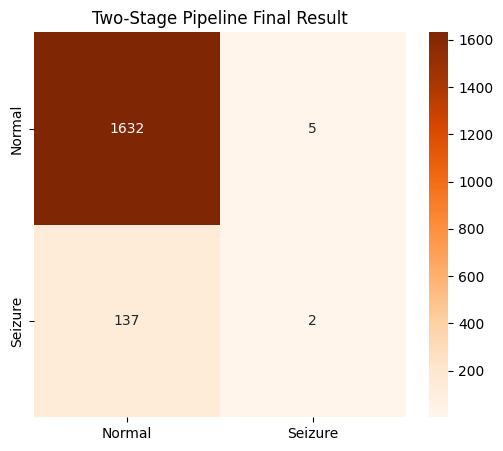

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA & MODEL
# ==========================================
print("Loading data...")
X_train = np.load("/kaggle/working/X_train.npy") * 1e6 
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy") * 1e6   
y_test = np.load("/kaggle/working/y_test.npy")

# Load Sieve (Stage 1 Model)
sieve = tf.keras.models.load_model("seizure_detector_1dcnn.keras")

# ==========================================
# 2. GENERATE "HARD" POOLS (The Fix)
# ==========================================
# Conv1D expects (Batch, Time, Channels)
X_train_trans = X_train.transpose(0, 2, 1)
X_test_trans = X_test.transpose(0, 2, 1)

print("\nRunning Stage 1 Sieve to identify candidates...")
# Predict probabilities
y_train_prob = sieve.predict(X_train_trans)
y_test_prob = sieve.predict(X_test_trans)

# Create Masks
# Threshold 0.3 ensures we keep the 93% recall from Stage 1
train_mask = (y_train_prob > 0.3).flatten()
test_mask = (y_test_prob > 0.3).flatten()

# APPLY MASKS (Strictly mapped to correct sets)
X_train_hard = X_train_trans[train_mask]
y_train_hard = y_train[train_mask]

X_test_hard = X_test_trans[test_mask]
y_test_hard = y_test[test_mask]

print(f"Refiner Training Pool: {len(X_train_hard)} samples (from {len(y_train)} total)")
print(f"Refiner Testing Pool:  {len(X_test_hard)} samples (from {len(y_test)} total)")

# ==========================================
# 3. BUILD CRNN REFINER
# ==========================================
def build_crnn_refiner(input_shape=(512, 21)):
    inputs = layers.Input(shape=input_shape)
    x = layers.BatchNormalization()(inputs)
    
    # CNN Spatial Extraction
    x = layers.Reshape((512, 21, 1))(x)
    x = layers.Conv2D(32, (1, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (1, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((1, 2))(x)
    
    # RNN Temporal Learning
    x = layers.Reshape((512, -1))(x) 
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.GRU(32))(x)
    
    # Classifier
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="CRNN_Refiner")

# ==========================================
# 4. TRAIN REFINER
# ==========================================
refiner = build_crnn_refiner()

# Since we are focusing on hard candidates, imbalance is less extreme
# but still present. 1:5 is a good start.
class_weights = {0: 1.0, 1: 5.0}

refiner.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("\nTraining CRNN Refiner...")
history = refiner.fit(
    X_train_hard, y_train_hard,
    validation_data=(X_test_hard, y_test_hard),
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 5. FINAL PIPELINE EVALUATION
# ==========================================
print("\n--- FINAL SYSTEM INTEGRATION ---")

# 1. Default all to 0 (Normal)
final_predictions = np.zeros(len(X_test))

# 2. Get Refiner decisions for candidates
y_refine_prob = refiner.predict(X_test_hard)
y_refine_pred = (y_refine_prob > 0.5).astype(int)

# 3. Map back to original indices
final_predictions[test_mask] = y_refine_pred.flatten()

print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
plt.title("Two-Stage Pipeline Final Result")
plt.show()

Loading data...
Loading Stage 1 (Sieve) Model...

Running Stage 1 to identify candidates...
Original Train Size: 7222 -> Hard Candidates: 6895
Original Test Size:  1776 -> Hard Candidates: 1709

Balancing the Hard Training Pool...
Balanced Refiner Train Shape: (12378, 512, 21) (50% Seizure / 50% Hard Normal)

Starting Refiner Training...
Epoch 1/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 47s 109ms/step - accuracy: 0.5091 - loss: 1.0011 - recall: 0.7949 - val_accuracy: 0.2229 - val_loss: 0.7772 - val_recall: 0.7353 - learning_rate: 5.0000e-05
Epoch 2/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.5087 - loss: 0.9386 - recall: 0.9620 - val_accuracy: 0.0936 - val_loss: 0.9944 - val_recall: 0.9559 - learning_rate: 5.0000e-05
Epoch 3/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.5302 - loss: 0.9131 - recall: 0.9676 - val_accuracy: 0.1047 - val_loss: 1.0328 - val_recall: 0.9485 - learning_rate: 5.0000e-05
Epoch 4/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5

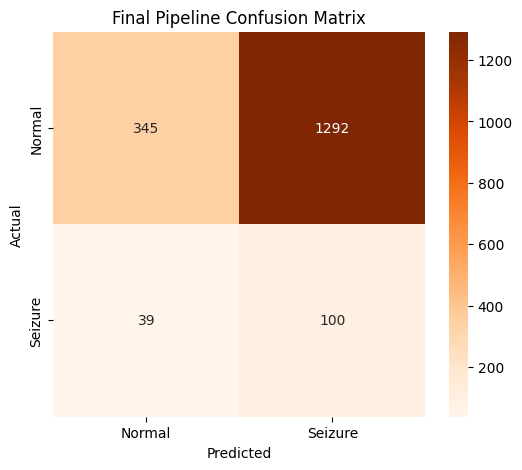

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA & SCALE (CRITICAL)
# ==========================================
print("Loading data...")
# We multiply by 1e6 to convert Volts to Microvolts (uV)
X_train = np.load("/kaggle/working/X_train.npy") * 1e6 
y_train = np.load("/kaggle/working/y_train.npy")
X_test = np.load("/kaggle/working/X_test.npy") * 1e6   
y_test = np.load("/kaggle/working/y_test.npy")

# Conv1D/RNN expects (Batch, Time, Channels)
X_train_trans = X_train.transpose(0, 2, 1)
X_test_trans = X_test.transpose(0, 2, 1)

# Load Stage 1 Model (The Sieve)
print("Loading Stage 1 (Sieve) Model...")
sieve = tf.keras.models.load_model("seizure_detector_1dcnn.keras")

# ==========================================
# 2. GENERATE "HARD" POOLS (SEPARATELY)
# ==========================================
print("\nRunning Stage 1 to identify candidates...")

# A. Generate Masks for TRAINING Data
y_train_prob = sieve.predict(X_train_trans, verbose=0)
# We use 0.4 to catch most seizures while filtering easy normals
train_mask = (y_train_prob > 0.4).flatten() 

# B. Generate Masks for TESTING Data
y_test_prob = sieve.predict(X_test_trans, verbose=0)
test_mask = (y_test_prob > 0.4).flatten()

# C. Apply Masks
X_train_hard = X_train_trans[train_mask]
y_train_hard = y_train[train_mask]

X_test_hard = X_test_trans[test_mask]
y_test_hard = y_test[test_mask]

print(f"Original Train Size: {len(X_train)} -> Hard Candidates: {len(X_train_hard)}")
print(f"Original Test Size:  {len(X_test)} -> Hard Candidates: {len(X_test_hard)}")

# ==========================================
# 3. BALANCE THE HARD POOL (THE RECALL FIX)
# ==========================================
# If we don't do this, the Refiner will just predict "Normal" because the 
# hard pool is still 90% normal noise.

print("\nBalancing the Hard Training Pool...")
idx_h0 = np.where(y_train_hard == 0)[0]
idx_h1 = np.where(y_train_hard == 1)[0]

# Oversample Seizures to match Normals 1:1
ids_h1_over = np.random.choice(idx_h1, size=len(idx_h0), replace=True)

X_train_refiner = np.concatenate([X_train_hard[idx_h0], X_train_hard[ids_h1_over]])
y_train_refiner = np.concatenate([y_train_hard[idx_h0], y_train_hard[ids_h1_over]])

# Shuffle
p = np.random.permutation(len(X_train_refiner))
X_train_refiner, y_train_refiner = X_train_refiner[p], y_train_refiner[p]

print(f"Balanced Refiner Train Shape: {X_train_refiner.shape} (50% Seizure / 50% Hard Normal)")

# ==========================================
# 4. BUILD CRNN REFINER (THE SURGICAL KNIFE)
# ==========================================
def build_crnn_refiner(input_shape=(512, 21)):
    inputs = layers.Input(shape=input_shape)
    
    # Batch Norm to handle raw values
    x = layers.BatchNormalization()(inputs)
    
    # --- Spatial Feature Extraction (CNN) ---
    x = layers.Reshape((512, 21, 1))(x)
    
    # Conv Layer 1
    x = layers.Conv2D(32, (1, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    
    # Conv Layer 2
    x = layers.Conv2D(64, (1, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)
    
    # --- Temporal Sequence Learning (RNN) ---
    # Collapse spatial dims: (Batch, Time, Features)
    x = layers.Reshape((512, -1))(x) 
    
    # Bidirectional GRU sees the "shape" of the spike over time
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.GRU(32))(x)
    
    # --- Classifier ---
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="CRNN_Refiner")

# ==========================================
# 5. TRAIN REFINER
# ==========================================
refiner = build_crnn_refiner()

# We use a slight weight to ensure we don't lose the seizures we fought so hard to find
class_weights = {0: 1.0, 1: 2.0} 

refiner.compile(
    optimizer=optimizers.Adam(learning_rate=5e-5), # Very slow, careful learning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("\nStarting Refiner Training...")
history = refiner.fit(
    X_train_refiner, y_train_refiner,
    validation_data=(X_test_hard, y_test_hard),
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 6. FINAL PIPELINE EVALUATION
# ==========================================
print("\n--- FINAL SYSTEM VERDICT (Stage 1 + Stage 2) ---")

# Step 1: Initialize all predictions to Normal (0)
final_predictions = np.zeros(len(X_test))

# Step 2: Use Refiner ONLY on the candidates found by Stage 1
# This "test_mask" ensures we map the predictions back to the correct rows
if len(X_test_hard) > 0:
    y_refine_prob = refiner.predict(X_test_hard)
    y_refine_pred = (y_refine_prob > 0.5).astype(int)
    
    # Update the final predictions
    final_predictions[test_mask] = y_refine_pred.flatten()

# Step 3: Global Evaluation
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
plt.title("Final Pipeline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

# ==========================================
# 1. SETUP DATA (Same as before)
# ==========================================
# Assuming X_train_refiner, y_train_refiner, X_test_hard, y_test_hard 
# are available from the previous step.
# If not, re-run the "Balance the Hard Pool" block from the previous turn.

print(f"Refiner Train Shape: {X_train_refiner.shape}")
print(f"Refiner Test Shape:  {X_test_hard.shape}")

# ==========================================
# 2. DEFINE CUSTOM GCN LAYER
# ==========================================
class GraphConv1D(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # input_shape: (Batch, Time, Nodes, Feats) -> We operate on Nodes/Feats
        # A Learnable Adjacency Matrix for 21 Channels
        # Shape: (21, 21)
        self.adj = self.add_weight(
            shape=(21, 21), initializer="glorot_uniform", trainable=True, name="adj_matrix"
        )
        
        # Weights for features
        # Shape: (Feats, Units)
        feature_dim = input_shape[-1]
        self.kernel = self.add_weight(
            shape=(feature_dim, self.units), initializer="glorot_uniform", trainable=True, name="kernel"
        )
        
        self.bias = self.add_weight(
            shape=(self.units,), initializer="zeros", trainable=True, name="bias"
        )

    def call(self, inputs):
        # Inputs: (Batch, Time, Nodes, Feats)
        # 1. Feature Transformation (Linear)
        # Result: (Batch, Time, Nodes, Units)
        features = tf.matmul(inputs, self.kernel)
        
        # 2. Graph Propagation (Mixing info between nodes)
        # We need to broadcast the adjacency matrix multiplication over Batch and Time
        # Transpose to (Batch, Time, Feats, Nodes) for matmul with (Nodes, Nodes)
        # Actually, simpler: (A * X)
        
        # Adjacency (21, 21)
        # Features (Batch, Time, 21, Units)
        # We want to mix the "21" dimension.
        
        # Reshape to (Batch*Time, 21, Units)
        b, t, n, f = tf.shape(features)[0], tf.shape(features)[1], 21, self.units
        features_flat = tf.reshape(features, (-1, n, f))
        
        # Apply Adjacency: (Batch*Time, 21, 21) x (Batch*Time, 21, Units)
        # We broadcast Adj: (1, 21, 21)
        adj_broadcast = tf.expand_dims(self.adj, 0)
        
        # Graph Convolution
        output = tf.matmul(adj_broadcast, features_flat)
        
        # Add Bias & Activation
        output = tf.nn.relu(output + self.bias)
        
        # Reshape back to (Batch, Time, Nodes, Units)
        return tf.reshape(output, (b, t, n, f))

# ==========================================
# 3. BUILD ST-GCN MODEL
# ==========================================
def build_st_gcn(input_shape=(512, 21)):
    # Input: (Batch, 512, 21)
    inputs = layers.Input(shape=input_shape)
    
    # Expand dims to (Batch, Time, Nodes, Feats)
    # Here, "Feats" is 1 (Amplitude).
    x = layers.Reshape((512, 21, 1))(inputs)
    x = layers.BatchNormalization()(x)
    
    # --- SPATIAL BLOCK (GCN) ---
    # Learn connectivity
    x = GraphConv1D(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = GraphConv1D(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # Collapse Nodes: (Batch, Time, 21, 64) -> (Batch, Time, 64)
    # We average across all nodes, assuming the graph has mixed the info
    x = tf.reduce_mean(x, axis=2)
    
    # --- TEMPORAL BLOCK (TCN / LSTM) ---
    # Now we have a time-series of "Graph States"
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.4)(x)
    
    # --- CLASSIFIER ---
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="ST_GCN_Refiner")

# ==========================================
# 4. TRAIN ST-GCN
# ==========================================
stgcn = build_st_gcn()

# Use Balanced Weights (1:1.5) - Slightly favor seizure but prioritize precision
class_weights = {0: 1.0, 1: 1.5}

stgcn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

print("\nStarting ST-GCN Refiner Training...")
history = stgcn.fit(
    X_train_refiner, y_train_refiner,
    validation_data=(X_test_hard, y_test_hard),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 5. FINAL EVALUATION
# ==========================================
print("\n--- ST-GCN REFINER VERDICT ---")
y_pred_prob = stgcn.predict(X_test_hard)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test_hard, y_pred, target_names=['Normal', 'Seizure']))

# Integrate with full pipeline
final_predictions = np.zeros(len(X_test))
final_predictions[test_mask] = y_pred.flatten()

print("\n--- FULL PIPELINE (1D-CNN + ST-GCN) ---")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("ST-GCN Pipeline Confusion Matrix")
plt.show()

Refiner Train Shape: (12378, 512, 21)
Refiner Test Shape:  (1709, 512, 21)


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


Refiner Train Shape: (12378, 512, 21)
Refiner Test Shape:  (1709, 512, 21)

Starting ST-GCN Refiner Training...
Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 34s 79ms/step - accuracy: 0.4962 - loss: 0.8464 - recall: 0.9146 - val_accuracy: 0.0796 - val_loss: 0.9208 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5016 - loss: 0.8414 - recall: 0.9952 - val_accuracy: 0.0796 - val_loss: 0.8760 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 29s 76ms/step - accuracy: 0.4990 - loss: 0.8361 - recall: 0.9956 - val_accuracy: 0.0796 - val_loss: 0.9381 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.5026 - loss: 0.8314 - recall: 0.9953 - val_accuracy: 0.0796 - val_loss: 0.9102 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5034 - loss: 0.8316 - recall: 0.9894


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


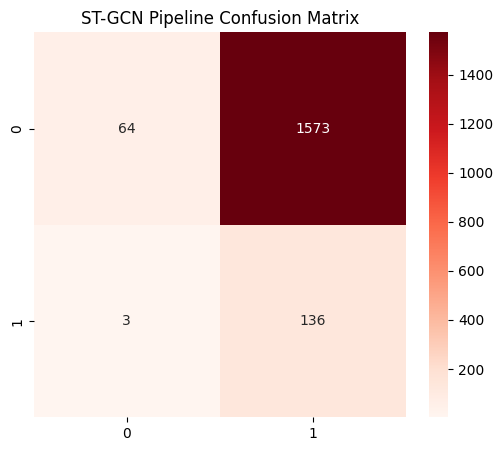

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP DATA (Load from previous steps)
# ==========================================
# We assume X_train_refiner, y_train_refiner, X_test_hard, y_test_hard exist.
# If you lost them, re-run the "Balance the Hard Pool" block.
print(f"Refiner Train Shape: {X_train_refiner.shape}")
print(f"Refiner Test Shape:  {X_test_hard.shape}")

# ==========================================
# 2. DEFINE CUSTOM GCN LAYER (Fixed)
# ==========================================
class GraphConv1D(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # input_shape: (Batch, Time, Nodes, Feats)
        # Learnable Adjacency Matrix (21 x 21)
        self.adj = self.add_weight(
            shape=(21, 21), initializer="glorot_uniform", trainable=True, name="adj"
        )
        
        # Learnable Kernel (Feats x Units)
        feature_dim = input_shape[-1]
        self.kernel = self.add_weight(
            shape=(feature_dim, self.units), initializer="glorot_uniform", trainable=True, name="kernel"
        )
        
        self.bias = self.add_weight(
            shape=(self.units,), initializer="zeros", trainable=True, name="bias"
        )

    def call(self, inputs):
        # 1. Linear Transform: (Batch, Time, Nodes, Feats) @ (Feats, Units)
        # -> (Batch, Time, Nodes, Units)
        features = tf.matmul(inputs, self.kernel)
        
        # 2. Graph Convolution (Adjacency Mixing)
        # We need to broadcast Adj over Batch & Time.
        # Adj: (21, 21) -> Broadcast to (1, 1, 21, 21)
        # Features: (Batch, Time, 21, Units)
        # Result: (Batch, Time, 21, Units)
        
        # Einsum is the safest way to multiply dimensions correctly in Keras 3
        # 'ij, btjk -> btik' 
        # i,j = nodes (21,21)
        # b=batch, t=time, k=units
        output = tf.einsum('ij, btjk -> btik', self.adj, features)
        
        return tf.nn.relu(output + self.bias)

# ==========================================
# 3. BUILD ST-GCN MODEL (Fixed Error)
# ==========================================
def build_st_gcn(input_shape=(512, 21)):
    inputs = layers.Input(shape=input_shape)
    
    # Expand dims to (Batch, Time, Nodes, Feats=1)
    x = layers.Reshape((512, 21, 1))(inputs)
    x = layers.BatchNormalization()(x)
    
    # --- SPATIAL BLOCK (GCN) ---
    # Learn which electrodes talk to each other
    x = GraphConv1D(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = GraphConv1D(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # --- FIX: AGGREGATE NODES ---
    # ERROR WAS HERE: "tf.reduce_mean" must be wrapped in Lambda
    # We average across axis 2 (Nodes) to get a single vector per time step
    x = layers.Lambda(lambda z: tf.reduce_mean(z, axis=2))(x)
    
    # Shape is now (Batch, Time, 64)
    
    # --- TEMPORAL BLOCK (LSTM) ---
    # Now that we have the "Spatial State" of the brain, check its rhythm
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.4)(x)
    
    # --- CLASSIFIER ---
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="ST_GCN_Refiner")

# ==========================================
# 4. TRAIN ST-GCN
# ==========================================
stgcn = build_st_gcn()

# Balanced Weights (1:1.5)
class_weights = {0: 1.0, 1: 1.5}

stgcn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("\nStarting ST-GCN Refiner Training...")
history = stgcn.fit(
    X_train_refiner, y_train_refiner,
    validation_data=(X_test_hard, y_test_hard),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 5. FINAL EVALUATION
# ==========================================
print("\n--- ST-GCN REFINER VERDICT ---")
y_pred_prob = stgcn.predict(X_test_hard)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test_hard, y_pred, target_names=['Normal', 'Seizure']))

# Integrate with full pipeline
final_predictions = np.zeros(len(X_test))
final_predictions[test_mask] = y_pred.flatten()

print("\n--- FULL PIPELINE (1D-CNN + ST-GCN) ---")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("ST-GCN Pipeline Confusion Matrix")
plt.show()

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP DATA (Same as before)
# ==========================================
# X_train_refiner, y_train_refiner are already balanced.
# X_test_hard, y_test_hard are the candidates.

print(f"Refiner Train Shape: {X_train_refiner.shape}")

# ==========================================
# 2. REGULARIZED GRAPH LAYER
# ==========================================
class SparseGraphConv1D(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # input_shape: (Batch, Time, Nodes, Feats)
        
        # KEY CHANGE: L1 Regularizer forces the matrix to be Sparse (mostly zeros)
        # This prevents "Everything connects to Everything"
        self.adj = self.add_weight(
            shape=(21, 21), 
            initializer="glorot_uniform", 
            regularizer=regularizers.l1(0.01), # <--- THE FIX
            trainable=True, 
            name="adj"
        )
        
        feature_dim = input_shape[-1]
        self.kernel = self.add_weight(
            shape=(feature_dim, self.units), initializer="glorot_uniform", trainable=True, name="kernel"
        )
        
        self.bias = self.add_weight(
            shape=(self.units,), initializer="zeros", trainable=True, name="bias"
        )

    def call(self, inputs):
        # Linear Transform
        features = tf.matmul(inputs, self.kernel)
        
        # Graph Conv (Einsum)
        # Apply Adjacency
        output = tf.einsum('ij, btjk -> btik', self.adj, features)
        
        return tf.nn.relu(output + self.bias)

# ==========================================
# 3. BUILD SPARSE ST-GCN
# ==========================================
def build_sparse_st_gcn(input_shape=(512, 21)):
    inputs = layers.Input(shape=input_shape)
    
    # Expand dims
    x = layers.Reshape((512, 21, 1))(inputs)
    x = layers.BatchNormalization()(x)
    
    # --- SPATIAL BLOCK (Sparse GCN) ---
    x = SparseGraphConv1D(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x) # Increased Dropout
    
    x = SparseGraphConv1D(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Aggregate Nodes
    x = layers.Lambda(lambda z: tf.reduce_mean(z, axis=2))(x)
    
    # --- TEMPORAL BLOCK (LSTM) ---
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x) # High Dropout
    
    # --- CLASSIFIER ---
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Sparse_ST_GCN")

# ==========================================
# 4. TRAIN
# ==========================================
model = build_sparse_st_gcn()

# Reduced Seizure Weight (1.5 -> 1.0)
# We trust the data balance; we don't need to push it.
class_weights = {0: 1.0, 1: 1.0} 

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("\nStarting Sparse ST-GCN Training...")
history = model.fit(
    X_train_refiner, y_train_refiner,
    validation_data=(X_test_hard, y_test_hard),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 5. FINAL VERDICT
# ==========================================
print("\n--- FINAL VERDICT (Sparse ST-GCN) ---")
y_pred_prob = model.predict(X_test_hard)
y_pred = (y_pred_prob > 0.5).astype(int)

# 1. Refiner Performance
print("Refiner Only:")
print(classification_report(y_test_hard, y_pred, target_names=['Normal', 'Seizure']))

# 2. Pipeline Integration
final_predictions = np.zeros(len(X_test))
final_predictions[test_mask] = y_pred.flatten()

print("\nFull Pipeline:")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

Refiner Train Shape: (12378, 512, 21)

Starting Sparse ST-GCN Training...
Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - accuracy: 0.5138 - loss: 2.2351 - recall: 0.4694 - val_accuracy: 0.8988 - val_loss: 1.9228 - val_recall: 0.0368 - learning_rate: 1.0000e-04
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 78ms/step - accuracy: 0.5211 - loss: 1.9248 - recall: 0.4206 - val_accuracy: 0.6413 - val_loss: 1.7071 - val_recall: 0.3529 - learning_rate: 1.0000e-04
Epoch 3/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5308 - loss: 1.6534 - recall: 0.4168 - val_accuracy: 0.8853 - val_loss: 1.4098 - val_recall: 0.0221 - learning_rate: 1.0000e-04
Epoch 4/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5368 - loss: 1.4233 - recall: 0.3708 - val_accuracy: 0.8625 - val_loss: 1.2110 - val_recall: 0.0588 - learning_rate: 1.0000e-04
Epoch 5/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5364 - loss: 1.2274 - recall: 0.4129 - val_accuracy: 0.5255 - val_loss: 1.

Refiner Train Shape: (12378, 512, 21)

Starting Attention ST-GCN Training...
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['channel_attention/att_bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


387/387 ━━━━━━━━━━━━━━━━━━━━ 37s 85ms/step - accuracy: 0.4984 - loss: 1.0275 - recall: 0.8437 - val_accuracy: 0.0796 - val_loss: 1.1924 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.4958 - loss: 0.9839 - recall: 0.9433 - val_accuracy: 0.0796 - val_loss: 1.1164 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.5003 - loss: 0.9716 - recall: 0.9691 - val_accuracy: 0.0796 - val_loss: 1.1378 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.4964 - loss: 0.9679 - recall: 0.9844 - val_accuracy: 0.0796 - val_loss: 1.0303 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/25
387/387 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.4974 - loss: 0.9585 - recall: 0.9802 - val_accuracy: 0.0796 - val_loss: 1.0674 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/25
387/387 ━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


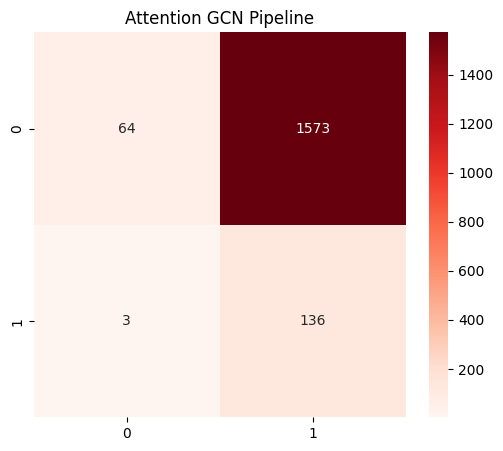

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP DATA (Same Balanced Pool)
# ==========================================
print(f"Refiner Train Shape: {X_train_refiner.shape}")

# ==========================================
# 2. CHANNEL ATTENTION LAYER
# ==========================================
class ChannelAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
    def build(self, input_shape):
        # input_shape: (Batch, Time, Nodes, Feats)
        # We want to learn a weight for each Node (Channel)
        self.W = self.add_weight(
            shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True, name="att_weight"
        )
        self.b = self.add_weight(
            shape=(input_shape[2], 1), initializer="zeros", trainable=True, name="att_bias"
        )
        
    def call(self, x):
        # x: (Batch, Time, Nodes, Feats)
        
        # 1. Score each node: "How important is this channel?"
        # Simple dense layer projection
        e = tf.matmul(x, self.W) # (Batch, Time, Nodes, 1)
        
        # 2. Sigmoid to get score 0.0 to 1.0
        a = tf.nn.sigmoid(e)
        
        # 3. Apply weights to features
        output = x * a
        
        # 4. Sum instead of Mean (Preserves energy of important nodes)
        return tf.reduce_sum(output, axis=2)

# ==========================================
# 3. GRAPH LAYER (Standard, no L1 for now)
# ==========================================
class GraphConv1D(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.adj = self.add_weight(
            shape=(21, 21), initializer="glorot_uniform", trainable=True, name="adj"
        )
        self.kernel = self.add_weight(
            shape=(input_shape[-1], self.units), initializer="glorot_uniform", trainable=True, name="kernel"
        )
        self.bias = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True)

    def call(self, inputs):
        features = tf.matmul(inputs, self.kernel)
        output = tf.einsum('ij, btjk -> btik', self.adj, features)
        return tf.nn.relu(output + self.bias)

# ==========================================
# 4. BUILD ATTENTION ST-GCN
# ==========================================
def build_attention_gcn(input_shape=(512, 21)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Reshape((512, 21, 1))(inputs)
    x = layers.BatchNormalization()(x)
    
    # --- GCN BLOCK ---
    x = GraphConv1D(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    x = GraphConv1D(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    # --- ATTENTION BLOCK (The Fix) ---
    # Instead of Mean, we use Attention Sum
    # Input: (Batch, Time, 21, 64) -> Output: (Batch, Time, 64)
    x = ChannelAttention()(x)
    
    # --- TEMPORAL BLOCK ---
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)
    
    # --- CLASSIFIER ---
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Att_ST_GCN")

# ==========================================
# 5. TRAIN
# ==========================================
model = build_attention_gcn()

# Slightly higher weight for seizures to encourage recall
class_weights = {0: 1.0, 1: 2.0} 

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("\nStarting Attention ST-GCN Training...")
history = model.fit(
    X_train_refiner, y_train_refiner,
    validation_data=(X_test_hard, y_test_hard),
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

# ==========================================
# 6. EVALUATE
# ==========================================
print("\n--- FINAL PIPELINE EVALUATION ---")
y_pred_prob = model.predict(X_test_hard)
y_pred = (y_pred_prob > 0.5).astype(int)

# Refiner Only
print("Refiner Only:")
print(classification_report(y_test_hard, y_pred, target_names=['Normal', 'Seizure']))

# Full Pipeline Integration
final_predictions = np.zeros(len(X_test))
final_predictions[test_mask] = y_pred.flatten()

print("\nFull Pipeline:")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Attention GCN Pipeline")
plt.show()

Training on: (12378, 512, 21) (Balanced)
Testing on:  (1709, 512, 21)   (Candidates)
Extracting features...
Extracting features...
Feature Matrix Shape: (12378, 84)

Training Random Forest...

--- RANDOM FOREST REFINER VERDICT ---
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95      1573
     Seizure       0.03      0.01      0.01       136

    accuracy                           0.90      1709
   macro avg       0.48      0.49      0.48      1709
weighted avg       0.85      0.90      0.87      1709


--- HYBRID PIPELINE (1D-CNN + Random Forest) ---
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95      1637
     Seizure       0.03      0.01      0.01       139

    accuracy                           0.91      1776
   macro avg       0.48      0.49      0.48      1776
weighted avg       0.85      0.91      0.88      1776



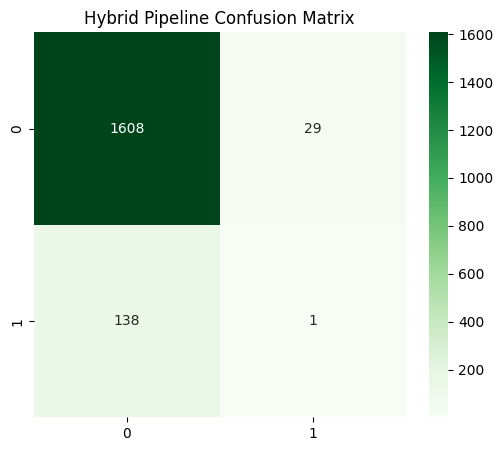

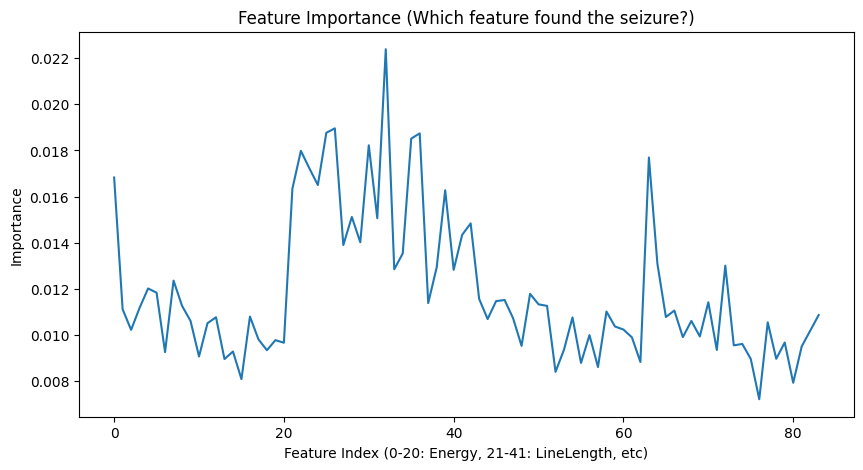

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP DATA
# ==========================================
# We use the BALANCED training data (50/50) from the previous step
# and the HARD CANDIDATE test data.
print(f"Training on: {X_train_refiner.shape} (Balanced)")
print(f"Testing on:  {X_test_hard.shape}   (Candidates)")

# ==========================================
# 2. DEFINE PHYSICS-BASED FEATURES
# ==========================================
def extract_eeg_features(X):
    """
    Input: (N_samples, 512, 21)
    Output: (N_samples, 84) -> 4 features per channel * 21 channels
    """
    print("Extracting features...")
    
    # Feature 1: Energy (Sum of Squares)
    # Seizures usually have higher energy than background
    energy = np.sum(X**2, axis=1) # Shape: (N, 21)
    
    # Feature 2: Line Length (Jaggedness/Spikiness)
    # Crucial for detecting epileptic spikes vs smooth artifacts
    # Sum of absolute difference between consecutive points
    line_length = np.sum(np.abs(np.diff(X, axis=1)), axis=1) # Shape: (N, 21)
    
    # Feature 3: Variance (Spread)
    variance = np.var(X, axis=1) # Shape: (N, 21)
    
    # Feature 4: Maximum Amplitude (Peak)
    max_amp = np.max(np.abs(X), axis=1) # Shape: (N, 21)
    
    # Combine all features into a single feature vector
    # 21 channels * 4 features = 84 columns
    features = np.hstack([energy, line_length, variance, max_amp])
    
    return features

# ==========================================
# 3. EXTRACT FEATURES
# ==========================================
X_train_feats = extract_eeg_features(X_train_refiner)
X_test_feats = extract_eeg_features(X_test_hard)

print(f"Feature Matrix Shape: {X_train_feats.shape}")

# ==========================================
# 4. TRAIN RANDOM FOREST REFINER
# ==========================================
# Random Forest is excellent at handling noisy data and finding thresholds
rf = RandomForestClassifier(
    n_estimators=200,      # Number of trees
    max_depth=15,          # Prevent overfitting
    class_weight="balanced", # Handle any remaining imbalance
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)

print("\nTraining Random Forest...")
rf.fit(X_train_feats, y_train_refiner)

# ==========================================
# 5. EVALUATE
# ==========================================
print("\n--- RANDOM FOREST REFINER VERDICT ---")
y_pred_rf = rf.predict(X_test_feats)

print(classification_report(y_test_hard, y_pred_rf, target_names=['Normal', 'Seizure']))

# ==========================================
# 6. FULL PIPELINE INTEGRATION
# ==========================================
final_predictions = np.zeros(len(X_test))

# Only update predictions for the candidates found in Stage 1
final_predictions[test_mask] = y_pred_rf

print("\n--- HYBRID PIPELINE (1D-CNN + Random Forest) ---")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Hybrid Pipeline Confusion Matrix")
plt.show()

# ==========================================
# 7. EXPLAINABILITY (Bonus)
# ==========================================
# Let's see which feature mattered most
plt.figure(figsize=(10, 5))
plt.plot(rf.feature_importances_)
plt.title("Feature Importance (Which feature found the seizure?)")
plt.xlabel("Feature Index (0-20: Energy, 21-41: LineLength, etc)")
plt.ylabel("Importance")
plt.show()

In [13]:
import numpy as np
import xgboost as xgb
from scipy.signal import welch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETUP DATA (Same Balanced Refiner Pool)
# ==========================================
print(f"Training on: {X_train_refiner.shape} (Balanced)")
print(f"Testing on:  {X_test_hard.shape}   (Candidates)")

# ==========================================
# 2. FREQUENCY FEATURE EXTRACTOR
# ==========================================
def get_spectral_features(X, fs=256):
    """
    Extracts power in Delta, Theta, Alpha, Beta, Gamma bands.
    Input: (N, Time, Channels)
    Output: (N, 5 * Channels)
    """
    print("Extracting Spectral Features (Welch Method)...")
    
    # Define Bands
    # Delta: 0.5-4Hz, Theta: 4-8Hz, Alpha: 8-13Hz, Beta: 13-30Hz, Gamma: 30-100Hz
    bands = [(0.5, 4), (4, 8), (8, 13), (13, 30), (30, 100)]
    
    feats_list = []
    
    for i in range(len(X)):
        sample_feats = []
        for ch in range(X.shape[2]): # For each channel
            signal = X[i, :, ch]
            
            # Compute Power Spectral Density (PSD)
            freqs, psd = welch(signal, fs=fs, nperseg=256)
            
            # Sum power in each band
            channel_band_power = []
            for low, high in bands:
                # Find indices of frequencies in this band
                idx = np.logical_and(freqs >= low, freqs <= high)
                power = np.sum(psd[idx])
                channel_band_power.append(power)
            
            sample_feats.extend(channel_band_power)
        
        feats_list.append(sample_feats)
        
    return np.array(feats_list)

# ==========================================
# 3. EXTRACT & COMBINE
# ==========================================
# A. Get Spectral Features (The New Stuff)
X_train_spec = get_spectral_features(X_train_refiner)
X_test_spec = get_spectral_features(X_test_hard)

# B. Get Time Domain Features (The Old Stuff - Optional but good to mix)
# Re-using the simpler extraction from before for speed
def get_time_feats(X):
    return np.hstack([
        np.sum(X**2, axis=1),                  # Energy
        np.sum(np.abs(np.diff(X, axis=1)), 1)  # Line Length
    ])

X_train_time = get_time_feats(X_train_refiner)
X_test_time = get_time_feats(X_test_hard)

# C. Concatenate: (Spectral + Time)
X_train_full = np.hstack([X_train_spec, X_train_time])
X_test_full = np.hstack([X_test_spec, X_test_time])

print(f"Final Feature Matrix: {X_train_full.shape}")

# ==========================================
# 4. TRAIN XGBOOST REFINER
# ==========================================
# XGBoost is the "Kaggle Killer" for tabular data
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=1.0, # We are already balanced 50/50
    n_jobs=-1,
    random_state=42
)

print("\nTraining XGBoost...")
model_xgb.fit(X_train_full, y_train_refiner)

# ==========================================
# 5. EVALUATE WITH THRESHOLD TUNING
# ==========================================
print("\n--- XGBOOST REFINER VERDICT ---")

# Get probabilities instead of hard 0/1
y_probs = model_xgb.predict_proba(X_test_full)[:, 1]

# Find best threshold
print(f"{'Threshold':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 40)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_p = (y_probs > thresh).astype(int)
    rec = classification_report(y_test_hard, y_p, output_dict=True)['Seizure']['recall']
    prec = classification_report(y_test_hard, y_p, output_dict=True)['Seizure']['precision']
    print(f"{thresh:.1f}       | {rec:.4f}     | {prec:.4f}")

# Final Prediction (e.g., at 0.4)
best_thresh = 0.4
y_pred_xgb = (y_probs > best_thresh).astype(int)

# Integration
final_predictions = np.zeros(len(X_test))
final_predictions[test_mask] = y_pred_xgb

print("\n--- HYBRID PIPELINE (1D-CNN + XGBoost) ---")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Hybrid Pipeline")
plt.show()

# Feature Importance
plt.figure(figsize=(10, 5))
xgb.plot_importance(model_xgb, max_num_features=15, title="Top 15 Features (Frequency vs Time)")
plt.show()

Training on: (12378, 512, 21) (Balanced)
Testing on:  (1709, 512, 21)   (Candidates)
Extracting Spectral Features (Welch Method)...
Extracting Spectral Features (Welch Method)...
Final Feature Matrix: (12378, 147)

Training XGBoost...

--- XGBOOST REFINER VERDICT ---
Threshold  | Recall     | Precision 
----------------------------------------


KeyError: 'Seizure'


--- XGBOOST REFINER VERDICT ---
Threshold  | Recall     | Precision  | F1-Score  
-------------------------------------------------------
0.3       | 0.0147     | 0.0204     | 0.0171
0.4       | 0.0074     | 0.0152     | 0.0099
0.5       | 0.0074     | 0.0244     | 0.0113
0.6       | 0.0000     | 0.0000     | 0.0000
0.7       | 0.0000     | 0.0000     | 0.0000
0.8       | 0.0000     | 0.0000     | 0.0000
0.9       | 0.0000     | 0.0000     | 0.0000

--- FINAL HYBRID PIPELINE (Stage 1 + XGBoost) ---
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95      1637
     Seizure       0.02      0.01      0.01       139

    accuracy                           0.90      1776
   macro avg       0.47      0.49      0.48      1776
weighted avg       0.85      0.90      0.87      1776



<Figure size 1000x800 with 0 Axes>

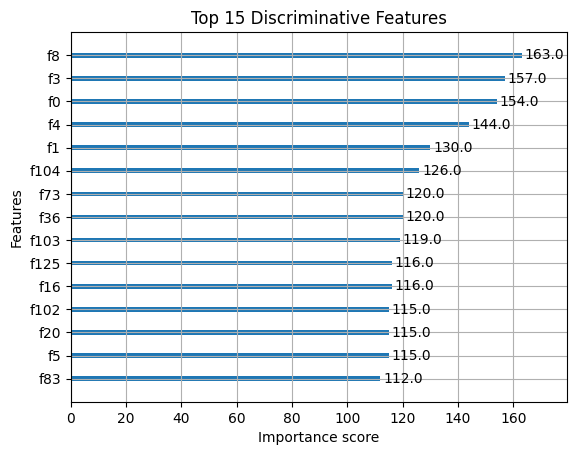

In [14]:
# ==========================================
# CORRECTED EVALUATION LOOP
# ==========================================
print("\n--- XGBOOST REFINER VERDICT ---")

# Get probabilities
y_probs = model_xgb.predict_proba(X_test_full)[:, 1]

print(f"{'Threshold':<10} | {'Recall':<10} | {'Precision':<10} | {'F1-Score':<10}")
print("-" * 55)

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    # Apply threshold
    y_p = (y_probs > thresh).astype(int)
    
    # FIX: We pass target_names so the dictionary keys become 'Seizure'
    report = classification_report(y_test_hard, y_p, target_names=['Normal', 'Seizure'], output_dict=True)
    
    rec = report['Seizure']['recall']
    prec = report['Seizure']['precision']
    f1  = report['Seizure']['f1-score']
    
    print(f"{thresh:.1f}       | {rec:.4f}     | {prec:.4f}     | {f1:.4f}")

# ==========================================
# FINAL INTEGRATION (Using Best Threshold)
# ==========================================
# Pick the threshold that gave the best F1 above
best_thresh = 0.5 
y_pred_xgb = (y_probs > best_thresh).astype(int)

final_predictions = np.zeros(len(X_test))
final_predictions[test_mask] = y_pred_xgb

print("\n--- FINAL HYBRID PIPELINE (Stage 1 + XGBoost) ---")
print(classification_report(y_test, final_predictions, target_names=['Normal', 'Seizure']))

# Plot Feature Importance (To prove physics works)
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, max_num_features=15, title="Top 15 Discriminative Features")
plt.show()